# Exploring and Preparing a Video Dataset

**Goal**: Focus is on how to work with video data and prepare it for face recognition tasks. Uses a YouTube video of an interview with an Indian Olympic boxer Mary Kom. Shortens the original video and extracts individual frames from it. The data will then be ready to be used with facial detection and recognition models.

**Objectives**

- Download a video data from YouTube. 

- Shorten the video and keep only the amount we need. 
 
- Extract frames from the video at regular intervals. 

- Display a subset of extracted frames.

**Getting started**

In [1]:
import subprocess
from pathlib import Path

import cv2
import matplotlib.pyplot as plt 
import pytubefix
import torch
import torchvision
from IPython.display import Video
from pytubefix import YouTube
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid

In [2]:
print("torch version : ", torch.__version__)
print("pytube version : ", pytubefix.__version__)
print("torchvision version : ", torchvision.__version__)
print("cv2 version : ", cv2.__version__)

!python --version

torch version :  2.5.1+cpu
pytube version :  8.12.3
torchvision version :  0.20.1+cpu
cv2 version :  4.11.0
Python 3.12.1


**Fetching YouTube Data**

Create a variable for the video directory using pathlib syntax.

In [11]:
data_dir = Path("data")
video_dir = data_dir 

print(video_dir)

data


Video Download:

In [4]:
video_name = "mary_kom.mp4"
video_url = "https://www.youtube.com/watch?v=XScnCdyVbIU"
yt = YouTube(video_url)

**Define Function** - A Python function that can cut down the video.

In [8]:
def cut_video(input_file, output_file, start__time, duration):
    """
    Cuts a portion of the video.

    input_file:parameter input_file: Path to the input video file.
    output_file:parameter output_file: Path to the output video file.
    start_time:parameter start_time: Start time of the cut in seconds or in `HH:MM:SS` format.
    duration:parameter duration: Duration of the cut in seconds or in `HH:MM:SS` format.
    """
    command = [
        "ffmpeg",
        "-ss",
        str(start_time),
        "-i",
        input_file,
        "-t",
        str(duration),
        "-c",
        "copy",
        output_file,
    ]
    subprocess.run(command)


cut_video?

Signature: cut_video(input_file, output_file, start__time, duration)
Docstring:
Cuts a portion of the video.

input_file:parameter input_file: Path to the input video file.
output_file:parameter output_file: Path to the output video file.
start_time:parameter start_time: Start time of the cut in seconds or in `HH:MM:SS` format.
duration:parameter duration: Duration of the cut in seconds or in `HH:MM:SS` format.
File:      c:\users\asus\appdata\local\temp\ipykernel_12968\644617062.py
Type:      function

Output path - A variable for the output video file path using pathlib.

In [12]:
output_video_name = "output.mp4"

output_video = video_dir/output_video_name

print(output_video)

data\output.mp4


In [ ]:
start_time = "00:00:00"  # Start at 00 seconds
duration = "00:01:00"  # Cut 1 minute

# Call cut_video function
cut_video(input_video, output_video, start_time, duration)

In [13]:
# Display the video
Video(output_video, width=400)

**Exploring and Preparing Data**

Video Capture for the one minute video output.

In [14]:
video_capture = cv2.VideoCapture(output_video)

if not video_capture.isOpened():
    print("Error: Could not open video.")
else:
    frame_rate = video_capture.get(cv2.CAP_PROP_FPS)
    frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Frame rate: {frame_rate}")
    print(f"Total number of frames: {frame_count}")

Frame rate: 25.0
Total number of frames: 1501


Fetch Frame - Fetching the first frame.

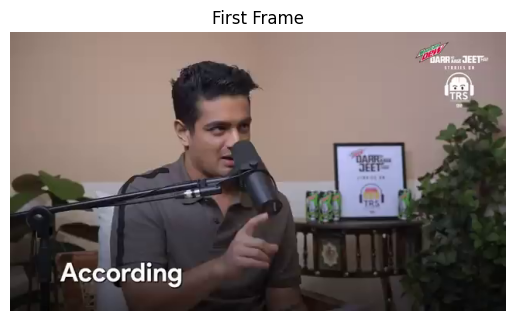

In [15]:
ret, first_frame = video_capture.read()

if ret:
    plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Error: Could not read frame.")

The shape of the first frame:

In [16]:
height, width, channel = first_frame.shape

print("frames height : ", height)
print("frames width : ", width)
print("frames channel : ", channel)

frames height :  360
frames width :  640
frames channel :  3


Frame directory path for the extracted frames using pathlib.

In [17]:
frames_dir = video_dir/"extracted_frames"

frames_dir.mkdir(exist_ok=True)
print(frames_dir)

data\extracted_frames


Save every fifth frame from the video.

In [18]:
interval = frame_rate * 0.20  # Extract every fifth frame from the video
frame_count = 0

print("Start extracting individual frames...")
while True:
    # read next frame from the video_capture
    ret, frame = video_capture.read()
    if not ret:
        print("Finished!")
        break  # Break the loop if there are no more frames

    # Save frames at every 'interval' frames
    if frame_count % 5 == 0:
        frame_path = frames_dir / f"frame_{frame_count}.jpg"
        cv2.imwrite(frame_path, frame)

    frame_count += 1

video_capture.release()

Start extracting individual frames...
Finished!


In [19]:
n_extraced_frames = len(list(frames_dir.iterdir()))
print(f"We saved {n_extraced_frames} frames.")

We saved 300 frames.


Display frames - display a grid sample frames.

In [25]:
def display_sample_images(dir_path, sample=5):
    image_list = []
    images = sorted(dir_path.iterdir())
    if images:
        sample_images = images[:sample]
        for sample_image in sample_images:
            image = read_image(str(sample_image))
            
            # Define resizing transformation that resizes to 240 x 240
            resize_transform = transforms.Resize((240, 240))
            # Resize image by using `resize_transform`
            image = resize_transform(image)
            image_list.append(image)
    grid = make_grid(image_list, nrow=5)
    image = to_pil_image(grid)
    return image


display_sample_images?

Signature: display_sample_images(dir_path, sample=5)
Docstring: <no docstring>
File:      c:\users\asus\appdata\local\temp\ipykernel_12968\3359215917.py
Type:      function

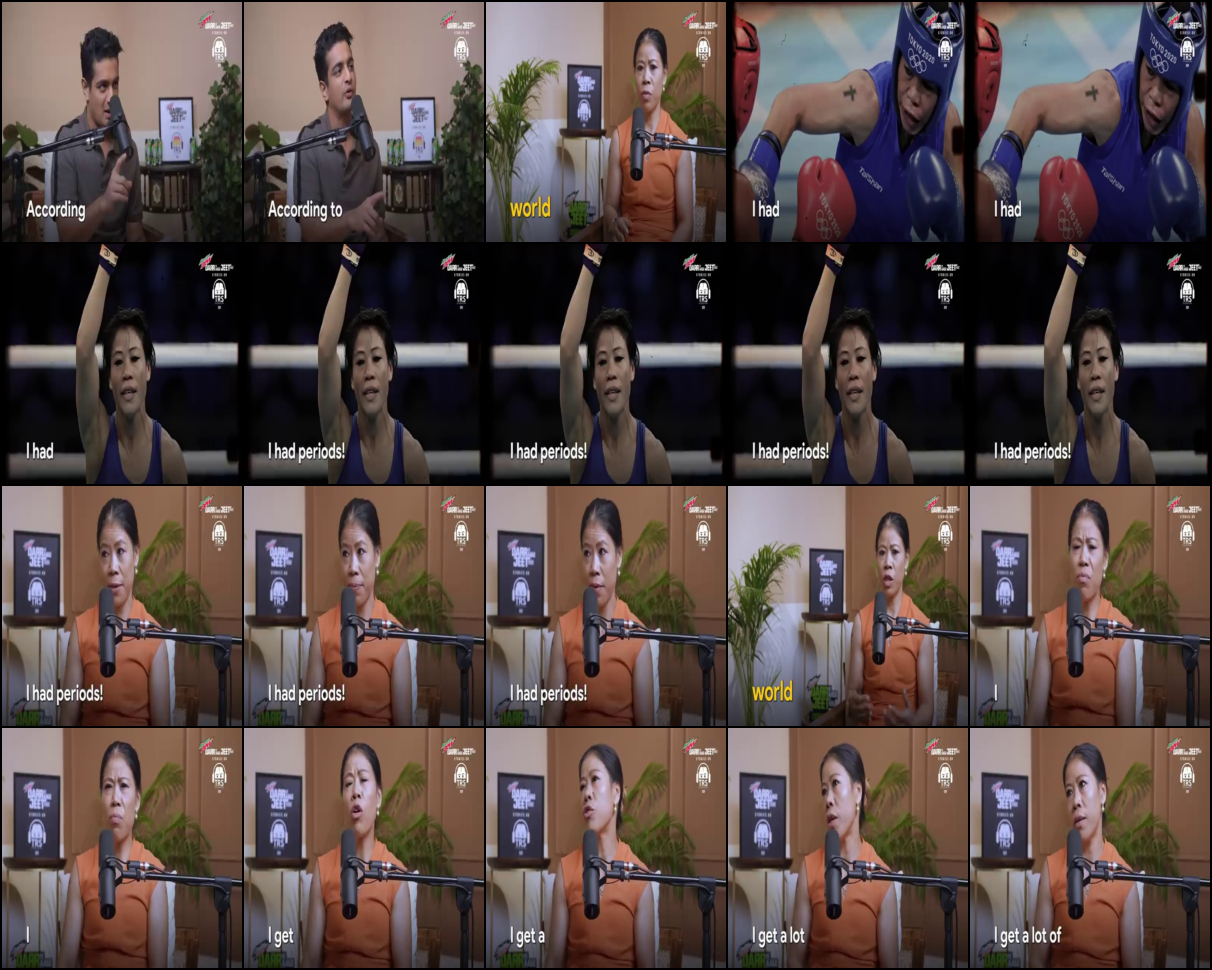

In [26]:
# Call function `display_sample_images` on `frames_dir`
display_sample_images(frames_dir, sample=20)